# Retrieval fine-tuning vs pretrained (IMC25)

This notebook compares **pretrained** vs **fine-tuned** retrieval embeddings on the IMC25 training set.

What you will see:
- Quantitative retrieval metrics (**Recall@1**, **Recall@5**) on a held-out validation split.
- Visual plots showing separation of "same scene" vs "different scene" similarities.
- Qualitative nearest-neighbor examples (images).

This is the same idea used in the pipeline:

- `train_retrieval.py` learns embeddings that group images from the same scene.
- `build_retrieval_cache.py` embeds test images.
- `cluster_retrieval.py` clusters those embeddings.

> Tip: Start Jupyter from the repo root so relative paths like `data/train` work.


In [1]:
from __future__ import annotations

import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader


def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    while p != p.parent:
        if (p / "src").exists() and (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("Could not find repo root (expected src/ and pyproject.toml)")


REPO_ROOT = _find_repo_root()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("repo:", REPO_ROOT)
print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


repo: /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025
HF_ENDPOINT: https://hf-mirror.com
torch: 2.9.1+cu130
cuda available: True


## Parameters

- `MODEL_ID` is the pretrained backbone used for both runs.
- `CHECKPOINT` is produced by `scripts/train_retrieval.py`.

If you haven’t trained yet:
```bash
HF_ENDPOINT=https://hf-mirror.com python scripts/train_retrieval.py --model-id facebook/dinov2-small --output-dir outputs/retrieval_finetune
```


In [2]:
MODEL_ID = "facebook/dinov2-small"

DATA_ROOT = REPO_ROOT / "data" / "train"
LABELS_CSV = REPO_ROOT / "data" / "train_labels.csv"

CHECKPOINT = REPO_ROOT / "outputs" / "retrieval_finetune" / "best.pt"

SEED = 42
VAL_RATIO = 0.1
BATCH_SIZE = 48

# To avoid multiprocessing permission issues on some systems, keep num_workers=0.
NUM_WORKERS = 0

assert DATA_ROOT.exists(), f"Missing {DATA_ROOT}"
assert LABELS_CSV.exists(), f"Missing {LABELS_CSV}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Load train labels and create a validation split

We build samples from `data/train_labels.csv`:
- Each image gets a label `dataset/scene`.
- (Optional) unlabeled images in train folders can be treated as unique outlier labels.

We then create a stratified split so each label keeps at least 1 example in train.


In [3]:
from imc25.train.retrieval_data import RetrievalImageDataset, build_train_samples, split_train_val
from imc25.train.retrieval_transforms import load_transform_spec, make_eval_transform

samples, id_to_name = build_train_samples(
    data_root=DATA_ROOT,
    labels_csv=LABELS_CSV,
    datasets=None,
    include_outliers=True,
)

train_samples, val_samples = split_train_val(samples, val_ratio=VAL_RATIO, seed=SEED)

print("samples:", len(samples))
print("train:", len(train_samples))
print("val:", len(val_samples))

spec = load_transform_spec(model_id=MODEL_ID, hf_endpoint=os.environ.get("HF_ENDPOINT"))
eval_tf = make_eval_transform(spec)
val_ds = RetrievalImageDataset(val_samples, transform=eval_tf)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

val_paths = [s.path for s in val_samples]
val_label_ids = [int(s.label) for s in val_samples]
val_label_names = [id_to_name[int(lbl)] for lbl in val_label_ids]

pd.Series(val_label_names).value_counts().head(10)


samples: 1945
train: 1747
val: 198


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


amy_gardens/peach                                    20
pt_stpeters_stpauls/st_peters_square                 10
pt_piazzasanmarco_grandplace/grand_place_brussels    10
pt_stpeters_stpauls/st_pauls_cathedral               10
imc2024_lizard_pond/pond                              9
imc2024_lizard_pond/lizard                            9
fbk_vineyard/vineyard_split_3                         8
pt_sacrecoeur_trevi_tajmahal/taj_mahal                8
imc2023_heritage/dioscuri                             8
pt_brandenburg_british_buckingham/british_museum      8
Name: count, dtype: int64

## Metric: Recall@K

Recall@K measures: *"for each query image, is there at least one correct same-scene image in the top‑K nearest neighbors?"*

We exclude labels that appear only once in the validation set (because they have no possible same-label neighbor).


In [4]:
def recall_at_k(z: torch.Tensor, y: torch.Tensor, ks=(1, 5)) -> dict[str, float]:
    z = F.normalize(z.float(), p=2, dim=1)
    y = y.to(dtype=torch.int64)
    n = int(z.shape[0])
    if n <= 1:
        return {f"r@{k}": 0.0 for k in ks}

    uniq, counts = torch.unique(y, return_counts=True)
    count_map = dict(zip(uniq.tolist(), counts.tolist()))
    valid = torch.tensor([count_map[int(lbl)] > 1 for lbl in y.tolist()], dtype=torch.bool)
    if not bool(valid.any()):
        return {f"r@{k}": 0.0 for k in ks}

    z = z[valid]
    y = y[valid]

    sim = z @ z.T
    sim.fill_diagonal_(-1e9)
    kmax = int(max(ks))
    idx = sim.topk(k=min(kmax, z.shape[0] - 1), dim=1).indices
    hits = y[idx] == y.view(-1, 1)

    out = {}
    for k in ks:
        kk = int(min(k, hits.shape[1]))
        out[f"r@{k}"] = float(hits[:, :kk].any(dim=1).float().mean().item())
    return out


## Compute embeddings

We compare:
- **Pretrained baseline**: backbone pooled output (CLS token) from `MODEL_ID`.
- **Fine-tuned**: `RetrievalEmbedder` loaded from `CHECKPOINT`.


In [5]:
from imc25.train.retrieval_model import RetrievalEmbedder, RetrievalModelConfig, _load_backbone, _pool_output


@torch.inference_mode()
def embed_with_backbone(model_id: str) -> tuple[torch.Tensor, torch.Tensor]:
    backbone = _load_backbone(model_id).to(device)
    backbone.eval()
    zs = []
    ys = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        out = backbone(pixel_values=xb)
        z = _pool_output(out)
        z = F.normalize(z.float(), p=2, dim=1)
        zs.append(z.cpu())
        ys.append(yb.cpu())
    return torch.cat(zs, dim=0), torch.cat(ys, dim=0)


@torch.inference_mode()
def embed_with_checkpoint(ckpt_path: Path) -> tuple[torch.Tensor, torch.Tensor]:
    state = torch.load(ckpt_path, map_location="cpu")
    cfg = RetrievalModelConfig(**state["model_cfg"])
    model = RetrievalEmbedder(cfg)
    model.load_state_dict(state["state_dict"], strict=True)
    model = model.to(device)
    model.eval()
    zs = []
    ys = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        z = model(xb).float()
        zs.append(z.cpu())
        ys.append(yb.cpu())
    return torch.cat(zs, dim=0), torch.cat(ys, dim=0)


z_base, y_val = embed_with_backbone(MODEL_ID)
metrics_base = recall_at_k(z_base, y_val)

metrics_ft = None
z_ft = None
if CHECKPOINT.exists():
    z_ft, y_val_ft = embed_with_checkpoint(CHECKPOINT)
    metrics_ft = recall_at_k(z_ft, y_val_ft)
else:
    print("Checkpoint not found:", CHECKPOINT)

pd.DataFrame(
    [
        {"model": "pretrained_backbone", **metrics_base},
        {"model": "finetuned_checkpoint", **(metrics_ft or {})},
    ]
)


,model,r@1,r@5
0,pretrained_backbone,0.866667,0.974359
1,finetuned_checkpoint,0.897436,0.979487


## Visual 1: Similarity distributions (same scene vs different scene)

We look at cosine similarity between image embeddings.

- **Same label** pairs should have higher similarity.
- **Different label** pairs should have lower similarity.

If fine-tuning helped, you typically see:
- positive pairs shift right (higher similarity)
- negative pairs shift left (lower similarity)


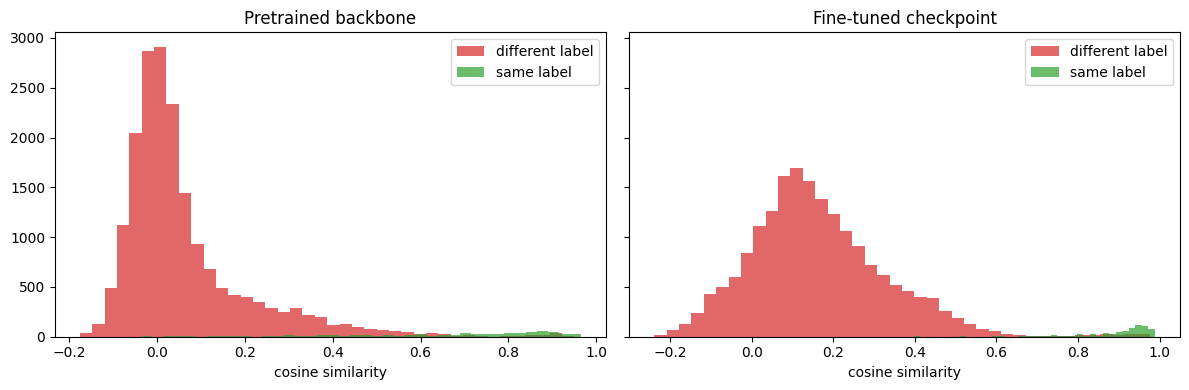

In [6]:
def pair_sims(z: torch.Tensor, y: torch.Tensor, *, max_pairs: int = 80_000):
    z = F.normalize(z.float(), p=2, dim=1)
    y = y.to(dtype=torch.int64)
    n = int(z.shape[0])
    # sample pairs for speed
    pairs = []
    rng = random.Random(SEED)
    for _ in range(min(max_pairs, n * (n - 1) // 2)):
        i = rng.randrange(0, n)
        j = rng.randrange(0, n)
        if i == j:
            continue
        if i > j:
            i, j = j, i
        pairs.append((i, j))

    i = torch.tensor([p[0] for p in pairs], dtype=torch.long)
    j = torch.tensor([p[1] for p in pairs], dtype=torch.long)
    sim = (z[i] * z[j]).sum(dim=1).cpu().numpy()
    same = (y[i] == y[j]).cpu().numpy().astype(bool)
    return sim[same], sim[~same]


pos_b, neg_b = pair_sims(z_base, y_val)

fig, ax = plt.subplots(1, 2 if z_ft is not None else 1, figsize=(12, 4), sharey=True)
ax = np.array(ax).reshape(-1)

ax[0].hist(neg_b, bins=40, alpha=0.7, label="different label", color="#d62728")
ax[0].hist(pos_b, bins=40, alpha=0.7, label="same label", color="#2ca02c")
ax[0].set_title("Pretrained backbone")
ax[0].set_xlabel("cosine similarity")
ax[0].legend()

if z_ft is not None:
    pos_f, neg_f = pair_sims(z_ft, y_val)
    ax[1].hist(neg_f, bins=40, alpha=0.7, label="different label", color="#d62728")
    ax[1].hist(pos_f, bins=40, alpha=0.7, label="same label", color="#2ca02c")
    ax[1].set_title("Fine-tuned checkpoint")
    ax[1].set_xlabel("cosine similarity")
    ax[1].legend()

plt.tight_layout()
plt.show()


## Visual 2: 2D projection (t-SNE) of validation embeddings

This is a *visualization only* (t-SNE is not used in the actual pipeline). We color the most frequent labels and group the rest as "other".


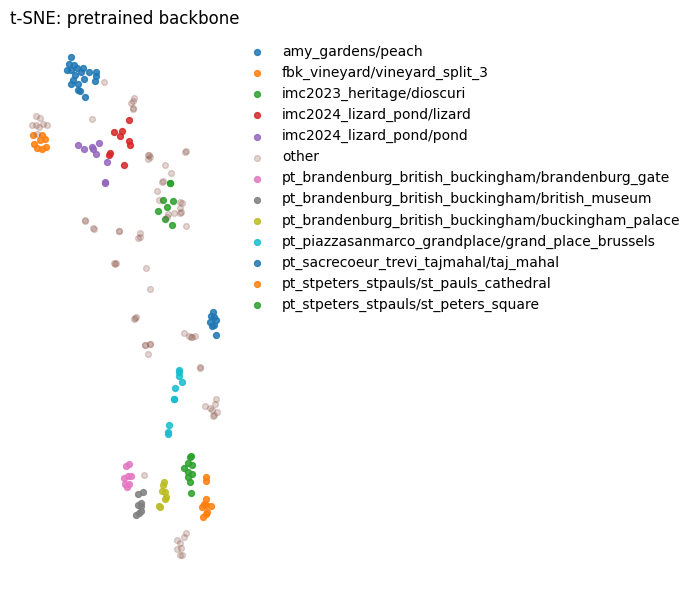

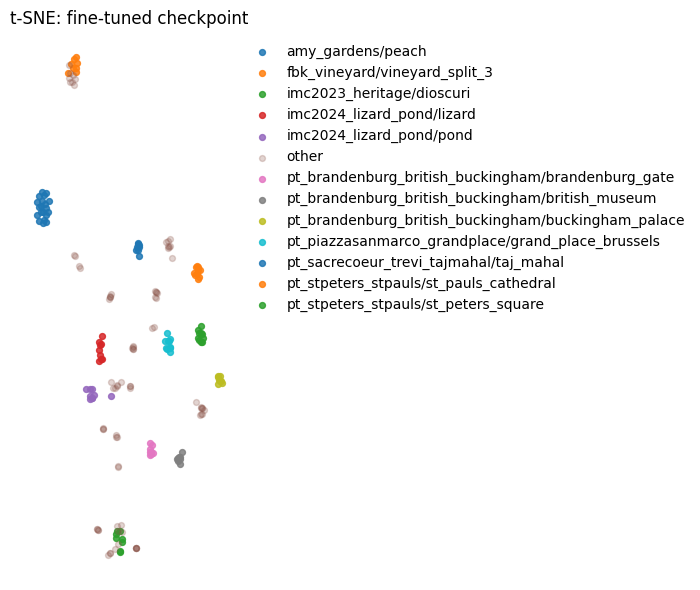

In [7]:
def make_label_groups(y: torch.Tensor, id_to_name: dict[int, str], top_n: int = 12):
    y = y.to(dtype=torch.int64)
    counts = pd.Series([int(x) for x in y.tolist()]).value_counts()
    top = set(counts.head(top_n).index.tolist())
    names = [id_to_name[int(i)] for i in y.tolist()]
    groups = [n if int(lbl) in top else "other" for lbl, n in zip(y.tolist(), names, strict=False)]
    return groups


def tsne_plot(z: torch.Tensor, y: torch.Tensor, title: str):
    z = z.cpu().numpy().astype(np.float32)
    groups = make_label_groups(y, id_to_name, top_n=12)
    xy = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=20, random_state=SEED).fit_transform(z)
    dfp = pd.DataFrame({"x": xy[:, 0], "y": xy[:, 1], "group": groups})

    plt.figure(figsize=(7, 6))
    for g, sub in dfp.groupby("group"):
        alpha = 0.25 if g == "other" else 0.85
        plt.scatter(sub["x"], sub["y"], s=18, alpha=alpha, label=g)
    plt.title(title)
    plt.axis("off")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()


tsne_plot(z_base, y_val, "t-SNE: pretrained backbone")
if z_ft is not None:
    tsne_plot(z_ft, y_val, "t-SNE: fine-tuned checkpoint")


## Visual 3: Nearest-neighbor retrieval examples

For a few random validation images, we show the top‑5 neighbors under:
- pretrained backbone embeddings
- fine-tuned checkpoint embeddings

Green title = same label, red title = different label.


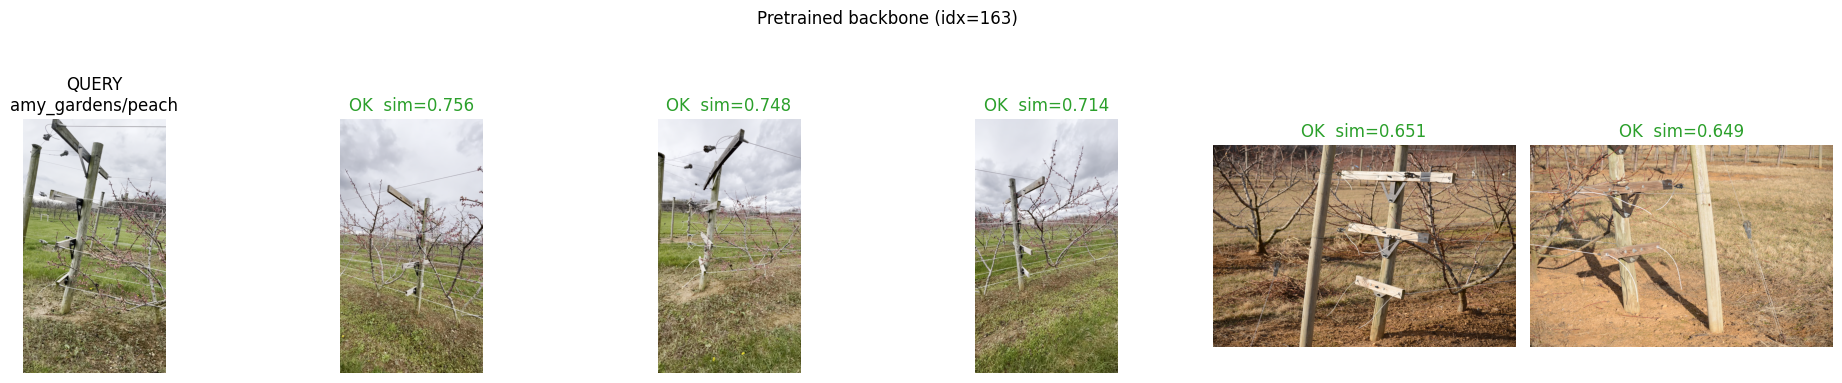

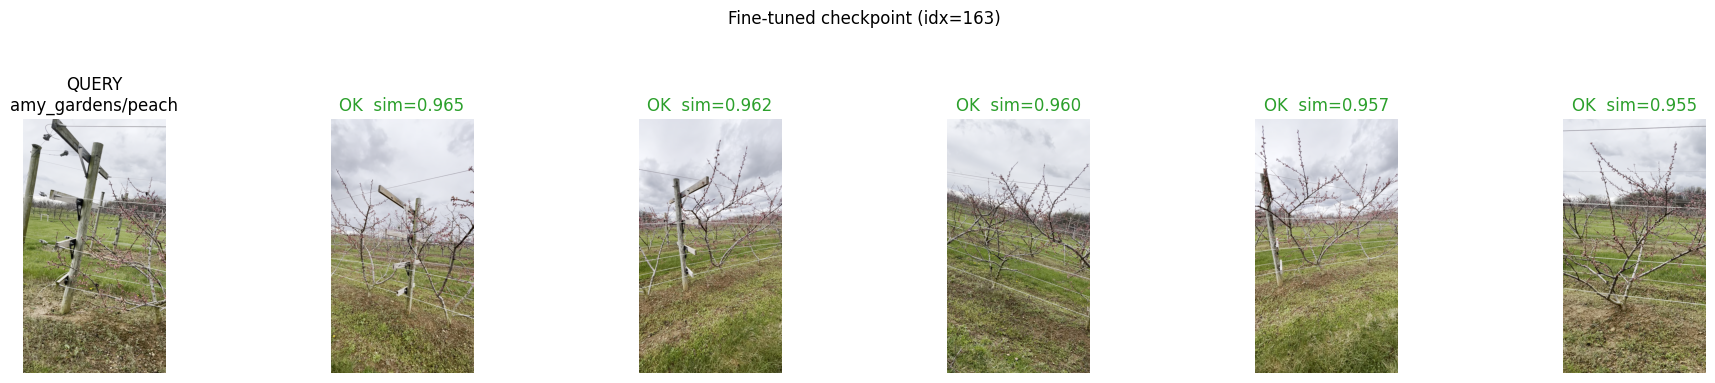

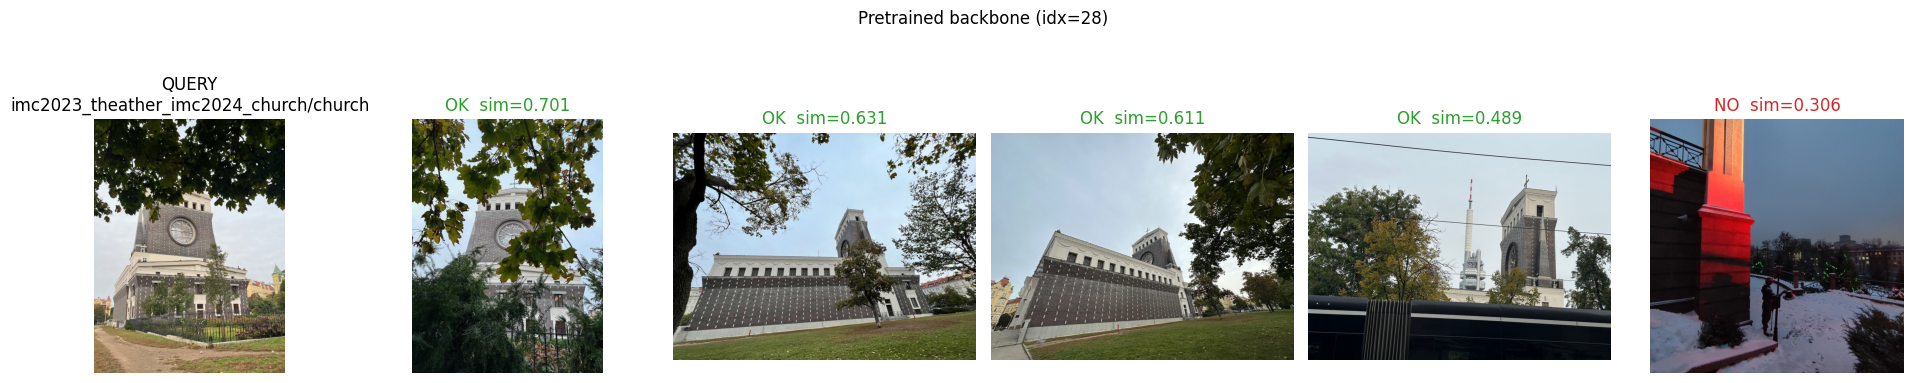

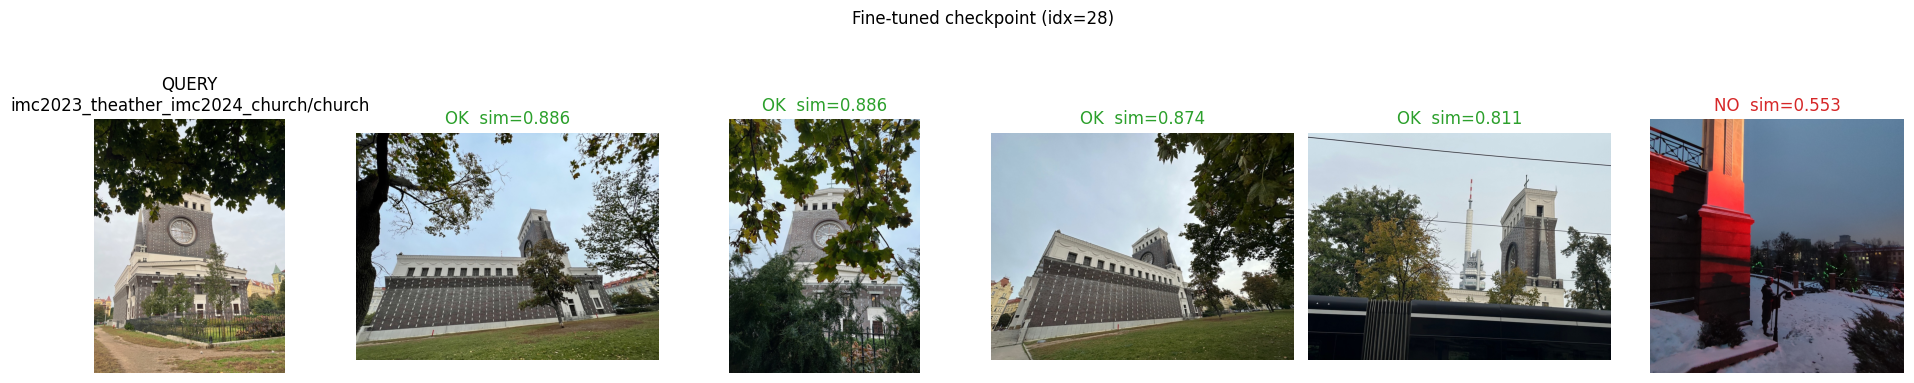

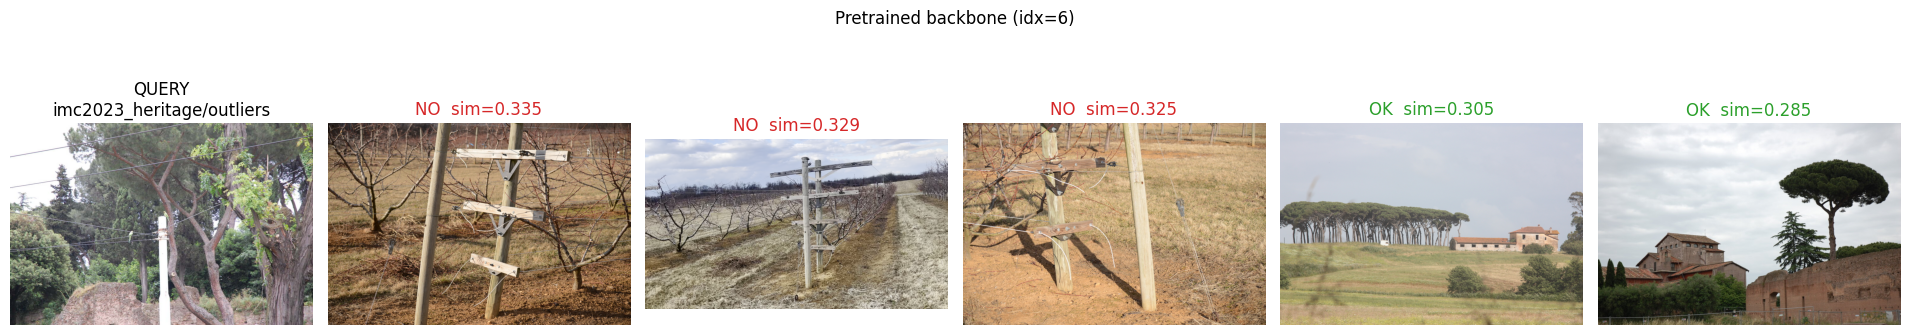

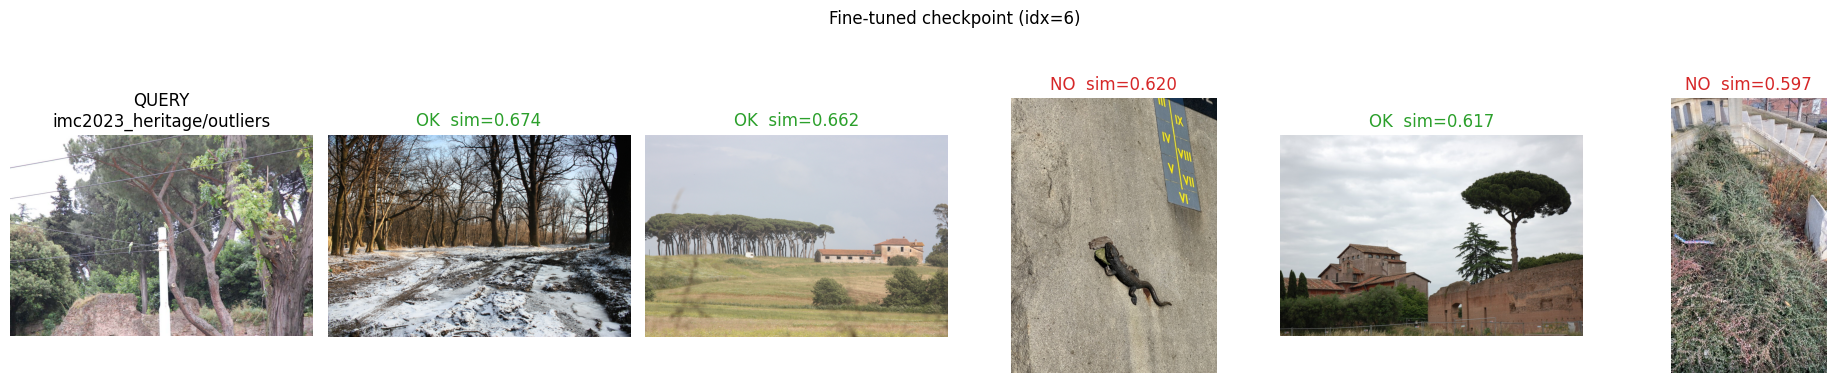

In [8]:
def topk_neighbors(z: torch.Tensor, idx: int, k: int = 5):
    z = F.normalize(z.float(), p=2, dim=1)
    q = z[idx : idx + 1]
    sim = (q @ z.T).squeeze(0)
    sim[idx] = -1e9
    vals, inds = torch.topk(sim, k=min(k, z.shape[0] - 1))
    return inds.cpu().tolist(), vals.cpu().tolist()


def show_query_and_neighbors(z: torch.Tensor, y: torch.Tensor, idx: int, title: str, k: int = 5):
    inds, sims = topk_neighbors(z, idx, k=k)
    y = y.to(dtype=torch.int64)
    q_label = int(y[idx].item())
    q_name = id_to_name[q_label]

    cols = k + 1
    fig, axes = plt.subplots(1, cols, figsize=(3.2 * cols, 3.6))

    def _load(p: Path):
        with Image.open(p) as im:
            return im.convert("RGB")

    axes[0].imshow(_load(val_paths[idx]))
    axes[0].axis("off")
    axes[0].set_title(f"QUERY\n{q_name}")

    for j, (nn_idx, s) in enumerate(zip(inds, sims, strict=False), start=1):
        nn_label = int(y[nn_idx].item())
        ok = nn_label == q_label
        color = "#2ca02c" if ok else "#d62728"
        axes[j].imshow(_load(val_paths[nn_idx]))
        axes[j].axis("off")
        axes[j].set_title(f"{('OK' if ok else 'NO')}  sim={s:.3f}", color=color)

    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


if z_ft is None:
    print("Fine-tuned checkpoint not found; skipping side-by-side examples.")
else:
    rng = random.Random(SEED)
    for idx in rng.sample(range(len(val_paths)), k=3):
        show_query_and_neighbors(z_base, y_val, idx, title=f"Pretrained backbone (idx={idx})")
        show_query_and_neighbors(z_ft, y_val, idx, title=f"Fine-tuned checkpoint (idx={idx})")
